Pre-simulating 50 × 1,000 games …
(~30–60 seconds — grab a chai ☕)

  [██░░░░░░░░░░░░░░░░░░░░░░] 5/50 done
  [█████░░░░░░░░░░░░░░░░░░░░] 10/50 done
  [███████░░░░░░░░░░░░░░░░░] 15/50 done
  [██████████░░░░░░░░░░░░░░░] 20/50 done
  [████████████░░░░░░░░░░░░] 25/50 done
  [███████████████░░░░░░░░░░] 30/50 done
  [█████████████████░░░░░░░] 35/50 done
  [████████████████████░░░░░] 40/50 done
  [██████████████████████░░] 45/50 done
  [█████████████████████████] 50/50 done

✅  Simulations done. Rendering GIF …



/var/folders/fw/s0bn00553knfn4xv4rfrddgm0000gn/T/ipykernel_1799/178457624.py:237: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  anim.save(SAVE_PATH, writer=writer, dpi=100,


💾  Saved → tambola_distribution.gif


/Users/sashivbhatia/py312/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/sashivbhatia/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


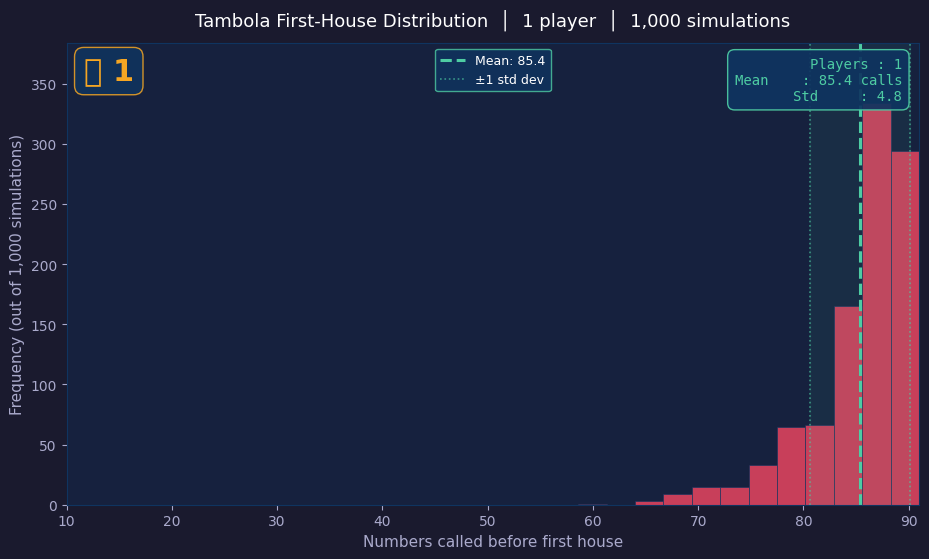

In [1]:
"""
=============================================================
TAMBOLA DISTRIBUTION GIF GENERATOR
=============================================================

Simulates 1,000 tambola games for each player count 1–50,
then saves an animated GIF showing how the first-house
distribution shifts as more players are added.

Dependencies:
    pip install matplotlib numpy pillow

Output:
    tambola_distribution.gif  (saved in current directory)
=============================================================
"""

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


# ─────────────────────────────────────────────────────────────
#  TAMBOLA SLIP GENERATION
# ─────────────────────────────────────────────────────────────

def generate_slip():
    """
    Generate one valid Tambola / Housie ticket.

    Rules:
      • 3 rows, 9 columns.
      • Each row has exactly 5 numbers and 4 blank cells.
      • Column ranges:
          col 0 → 1–9,  col 1 → 10–19, ...,  col 8 → 80–90
      • Numbers in each column are ascending top-to-bottom.
      • Every column has at least 1 number across the 3 rows.
      • Total = 15 numbers per slip.

    Returns:
        numbers: set of the 15 numbers on the slip.
    """
    col_ranges = [
        range(1, 10),   range(10, 20),  range(20, 30),
        range(30, 40),  range(40, 50),  range(50, 60),
        range(60, 70),  range(70, 80),  range(80, 91),
    ]

    while True:
        # Distribute 15 number slots across 9 columns (min 1 each)
        col_counts = [1] * 9
        remaining  = 6          # 15 - 9 = 6 extra slots
        cols       = list(range(9))
        random.shuffle(cols)
        for c in cols:
            if remaining == 0:
                break
            add = random.randint(0, min(2, remaining))
            col_counts[c] += add
            remaining     -= add
        for c in cols:          # top up if still short
            if remaining == 0:
                break
            if col_counts[c] < 3:
                col_counts[c] += 1
                remaining     -= 1

        if sum(col_counts) != 15:
            continue

        # Assign which rows in each column get a number
        mask = np.zeros((3, 9), dtype=bool)
        for c in range(9):
            for r in random.sample([0, 1, 2], col_counts[c]):
                mask[r, c] = True

        # Validate: every row must have exactly 5 numbers
        if not np.all(mask.sum(axis=1) == 5):
            continue

        # Fill actual numbers (ascending within each column)
        numbers = set()
        valid   = True
        for c in range(9):
            try:
                chosen = sorted(random.sample(list(col_ranges[c]), col_counts[c]))
            except ValueError:
                valid = False
                break
            rows = sorted(r for r in range(3) if mask[r, c])
            for r, num in zip(rows, chosen):
                numbers.add(num)

        if valid and len(numbers) == 15:
            return numbers


# ─────────────────────────────────────────────────────────────
#  GAME SIMULATION
# ─────────────────────────────────────────────────────────────

def simulate_one_game(n_players: int) -> int:
    """
    Simulate one tambola game and return the number of calls
    made when the first full house occurs.
    """
    player_numbers = [generate_slip() for _ in range(n_players)]

    call_order = list(range(1, 91))
    random.shuffle(call_order)

    seen = [set() for _ in range(n_players)]

    for call_count, number in enumerate(call_order, start=1):
        for i in range(n_players):
            if number in player_numbers[i]:
                seen[i].add(number)
            if seen[i] == player_numbers[i]:
                return call_count

    return 90


def run_simulations(n_players: int, n_simulations: int = 1000) -> list:
    """Run n_simulations games and return list of first-house call counts."""
    return [simulate_one_game(n_players) for _ in range(n_simulations)]


# ─────────────────────────────────────────────────────────────
#  GIF GENERATOR
# ─────────────────────────────────────────────────────────────

def generate_gif():
    N_SIMULATIONS = 1000
    MAX_PLAYERS   = 50
    SAVE_PATH     = "tambola_distribution.gif"

    # ── Pre-simulate all 50 player counts ─────────────────────
    print(f"Pre-simulating {MAX_PLAYERS} × {N_SIMULATIONS:,} games …")
    print("(~30–60 seconds — grab a chai ☕)\n")

    all_results = {}
    for n in range(1, MAX_PLAYERS + 1):
        all_results[n] = run_simulations(n, N_SIMULATIONS)
        if n % 5 == 0:
            filled = "█" * (n // 2)
            empty  = "░" * ((MAX_PLAYERS - n) // 2)
            print(f"  [{filled}{empty}] {n}/{MAX_PLAYERS} done")

    print("\n✅  Simulations done. Rendering GIF …\n")

    # ── Find a stable y-axis ceiling across all frames ─────────
    global_max_freq = max(
        np.histogram(all_results[n], bins=30, range=(10, 91))[0].max()
        for n in range(1, MAX_PLAYERS + 1)
    )
    y_limit = global_max_freq * 1.15

    # ── Set up figure ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("#1a1a2e")

    def draw_frame(n):
        """Draw one frame for player count n."""
        results = all_results[n]
        mean_v  = np.mean(results)
        std_v   = np.std(results)

        ax.cla()
        ax.set_facecolor("#16213e")

        # Histogram
        ax.hist(results, bins=30, range=(10, 91),
                color="#e94560", edgecolor="#0f3460",
                linewidth=0.5, alpha=0.85)

        # Mean line
        ax.axvline(mean_v, color="#4ecca3", linewidth=2.2,
                   linestyle="--", label=f"Mean: {mean_v:.1f}")

        # ±1 std dev lines + shaded region
        ax.axvline(mean_v - std_v, color="#4ecca3", linewidth=1.2,
                   linestyle=":", alpha=0.65)
        ax.axvline(mean_v + std_v, color="#4ecca3", linewidth=1.2,
                   linestyle=":", alpha=0.65, label="±1 std dev")
        ax.axvspan(mean_v - std_v, mean_v + std_v,
                   color="#4ecca3", alpha=0.07)

        # Axes
        ax.set_xlim(10, 91)
        ax.set_ylim(0, y_limit)
        ax.set_xlabel("Numbers called before first house",
                      color="#aaaacc", fontsize=11)
        ax.set_ylabel(f"Frequency (out of {N_SIMULATIONS:,} simulations)",
                      color="#aaaacc", fontsize=11)
        ax.tick_params(colors="#aaaacc")
        for spine in ax.spines.values():
            spine.set_edgecolor("#0f3460")

        # Title
        ax.set_title(
            f"Tambola First-House Distribution  │  "
            f"{n} player{'s' if n > 1 else ''}  │  {N_SIMULATIONS:,} simulations",
            color="white", fontsize=13, pad=12
        )

        # Stats box (top-right)
        ax.text(0.98, 0.97,
                f"Players : {n}\nMean    : {mean_v:.1f} calls\nStd     : {std_v:.1f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=10, color="#4ecca3", family="monospace",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#0f3460",
                          edgecolor="#4ecca3", alpha=0.92))

        # Player count badge (top-left)
        ax.text(0.02, 0.97, f"👥 {n}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=22, color="#f5a623", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#0f3460",
                          edgecolor="#f5a623", alpha=0.85))

        ax.legend(facecolor="#0f3460", edgecolor="#4ecca3",
                  labelcolor="white", fontsize=9, loc="upper center")

    # ── Build and save animation ───────────────────────────────
    anim = animation.FuncAnimation(
        fig,
        func         = draw_frame,
        frames       = range(1, MAX_PLAYERS + 1),
        interval     = 350,    # ms per frame (~3 fps)
        repeat       = True,
        repeat_delay = 1500    # 1.5 s pause before looping
    )

    writer = animation.PillowWriter(fps=3)
    anim.save(SAVE_PATH, writer=writer, dpi=100,
              savefig_kwargs={"facecolor": "#1a1a2e"})

    print(f"💾  Saved → {SAVE_PATH}")


if __name__ == "__main__":
    generate_gif()